# Olist 360 — Exploratory Data Analysis
## Understanding 100K+ real e-commerce orders

In [3]:
import pandas as pd 

In [4]:
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
import duckdb
import warnings
from pathlib import Path

In [5]:
BASE_DIR = Path().resolve().parent
conn = duckdb.connect(str(BASE_DIR / "data/warehouse/olist.duckdb"))
print("Connected to warehouse")

Connected to warehouse


In [6]:
## 1. Overview — How big is this dataset?

In [7]:
tables = {
    "fact_orders": "fact_orders",
    "dim_customer": "dim_customer",
    "dim_seller": "dim_seller",
    "dim_product": "dim_product",
    "dim_date": "dim_date",
    "dim_payment": "dim_payment",
    "dim_geolocation": "dim_geolocation"
}

print("=" * 40)
print("OLIST WAREHOUSE — TABLE OVERVIEW")
print("=" * 40)
for name, table in tables.items():
    count = conn.execute(f"SELECT COUNT(*) FROM {table}").fetchone()[0]
    print(f"{name:<20} {count:>10,} rows")
print("=" * 40)

OLIST WAREHOUSE — TABLE OVERVIEW
fact_orders              99,441 rows
dim_customer             99,441 rows
dim_seller                3,095 rows
dim_product              32,951 rows
dim_date                 98,875 rows
dim_payment             103,272 rows
dim_geolocation          19,023 rows


In [8]:
## 2. Order Trends — How did orders grow over time?

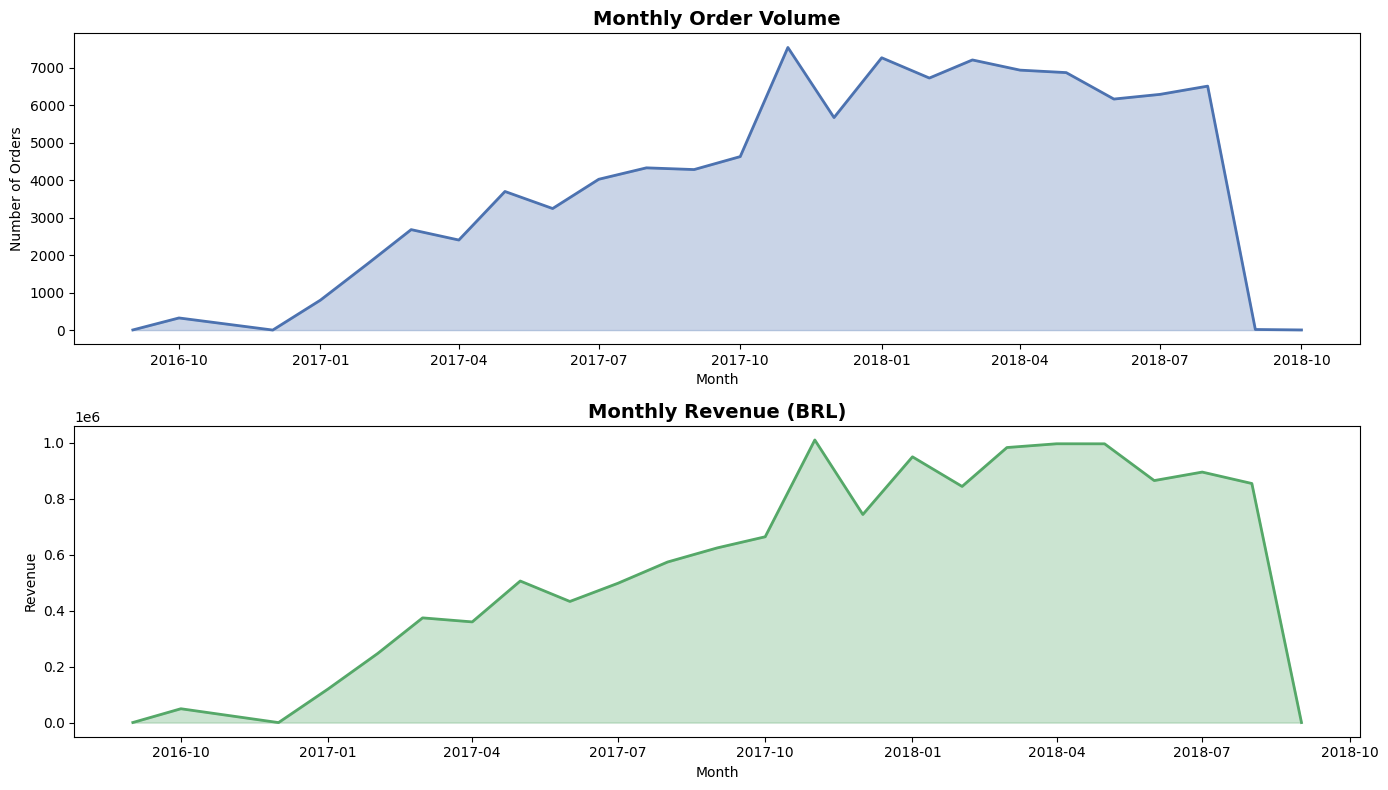

Chart saved


In [9]:
df_trend = conn.execute("""
    SELECT 
        DATE_TRUNC('month', order_purchase_timestamp) AS month,
        COUNT(*) AS total_orders,
        ROUND(SUM(total_price), 2) AS total_revenue
    FROM fact_orders
    WHERE order_purchase_timestamp IS NOT NULL
    GROUP BY 1
    ORDER BY 1
""").df()

# Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

# Orders over time
ax1.plot(df_trend["month"], df_trend["total_orders"], color="#4C72B0", linewidth=2)
ax1.fill_between(df_trend["month"], df_trend["total_orders"], alpha=0.3, color="#4C72B0")
ax1.set_title("Monthly Order Volume", fontsize=14, fontweight="bold")
ax1.set_xlabel("Month")
ax1.set_ylabel("Number of Orders")

# Revenue over time
ax2.plot(df_trend["month"], df_trend["total_revenue"], color="#55A868", linewidth=2)
ax2.fill_between(df_trend["month"], df_trend["total_revenue"], alpha=0.3, color="#55A868")
ax2.set_title("Monthly Revenue (BRL)", fontsize=14, fontweight="bold")
ax2.set_xlabel("Month")
ax2.set_ylabel("Revenue")

plt.tight_layout()
plt.savefig("../reports/figures/01_order_trends.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved")

In [10]:
## 3. Top Product Categories by Revenue

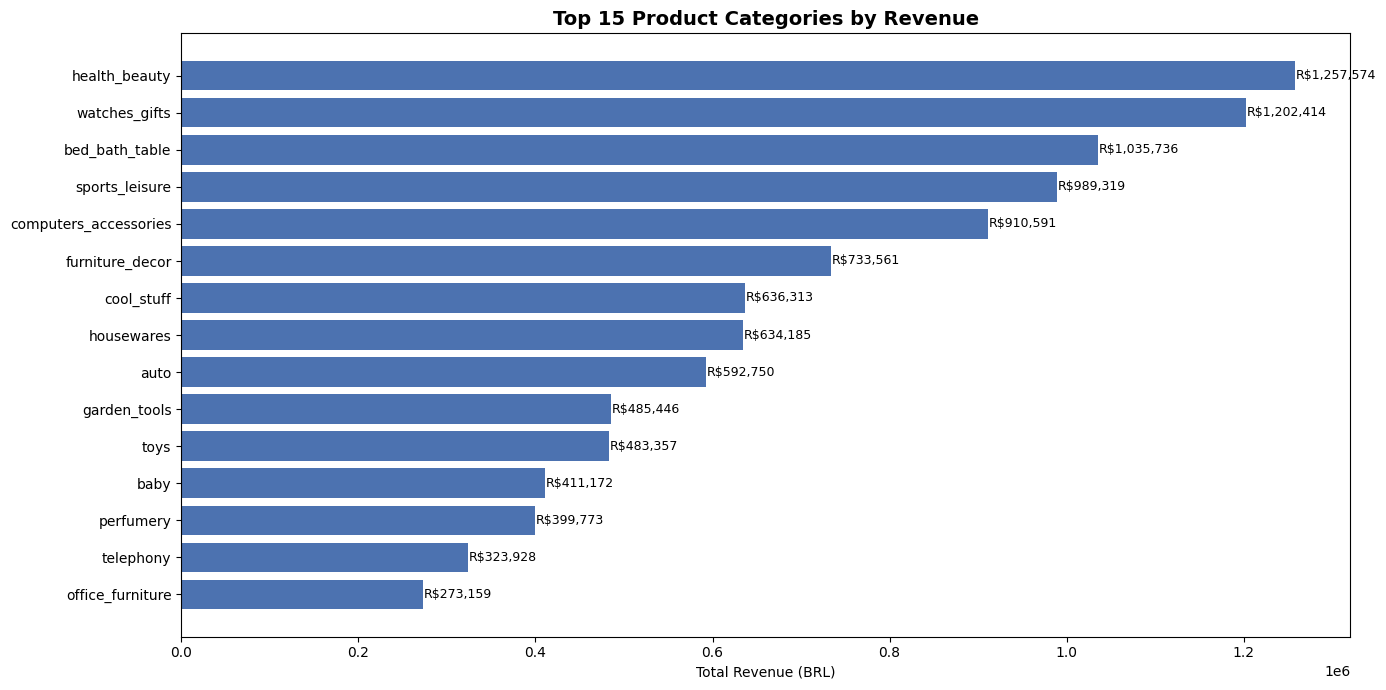

Chart saved


In [11]:
df_categories = conn.execute("""
    SELECT 
        p.product_category_name_english AS category,
        COUNT(*) AS total_orders,
        ROUND(SUM(f.total_price), 2) AS total_revenue
    FROM fact_orders f
    JOIN dim_product p ON f.product_id = p.product_id
    WHERE p.product_category_name_english IS NOT NULL
    GROUP BY 1
    ORDER BY total_revenue DESC
    LIMIT 15
""").df()

# Plot
fig, ax = plt.subplots(figsize=(14, 7))
bars = ax.barh(
    df_categories["category"],
    df_categories["total_revenue"],
    color="#4C72B0"
)
ax.set_title("Top 15 Product Categories by Revenue", fontsize=14, fontweight="bold")
ax.set_xlabel("Total Revenue (BRL)")
ax.invert_yaxis()

# Add value labels on bars
for bar, val in zip(bars, df_categories["total_revenue"]):
    ax.text(bar.get_width() + 1000, bar.get_y() + bar.get_height()/2,
            f"R${val:,.0f}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("../reports/figures/02_top_categories.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved")

In [12]:
## 4. Order Status Distribution

order_status  total_orders  percentage
   delivered         96478       97.02
     shipped          1107        1.11
    canceled           625        0.63
 unavailable           609        0.61
    invoiced           314        0.32
  processing           301        0.30
     created             5        0.01
    approved             2        0.00


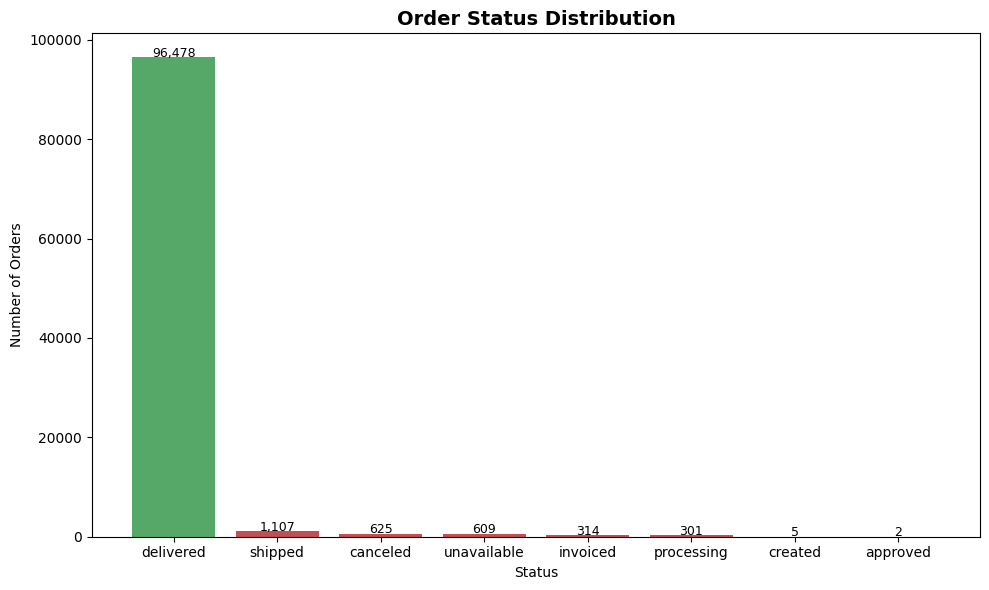

In [13]:
df_status = conn.execute("""
    SELECT 
        order_status,
        COUNT(*) AS total_orders,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2) AS percentage
    FROM fact_orders
    GROUP BY 1
    ORDER BY total_orders DESC
""").df()

print(df_status.to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#55A868" if s == "delivered" else "#C44E52" for s in df_status["order_status"]]
bars = ax.bar(df_status["order_status"], df_status["total_orders"], color=colors)
ax.set_title("Order Status Distribution", fontsize=14, fontweight="bold")
ax.set_xlabel("Status")
ax.set_ylabel("Number of Orders")

for bar, val in zip(bars, df_status["total_orders"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f"{val:,}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("../reports/figures/03_order_status.png", dpi=150, bbox_inches="tight")
plt.show()

In [14]:
## 5. Delivery Performance — On Time vs Late

delivery_status  total_orders  percentage
           Late          7827        7.87
        On Time         91614       92.13


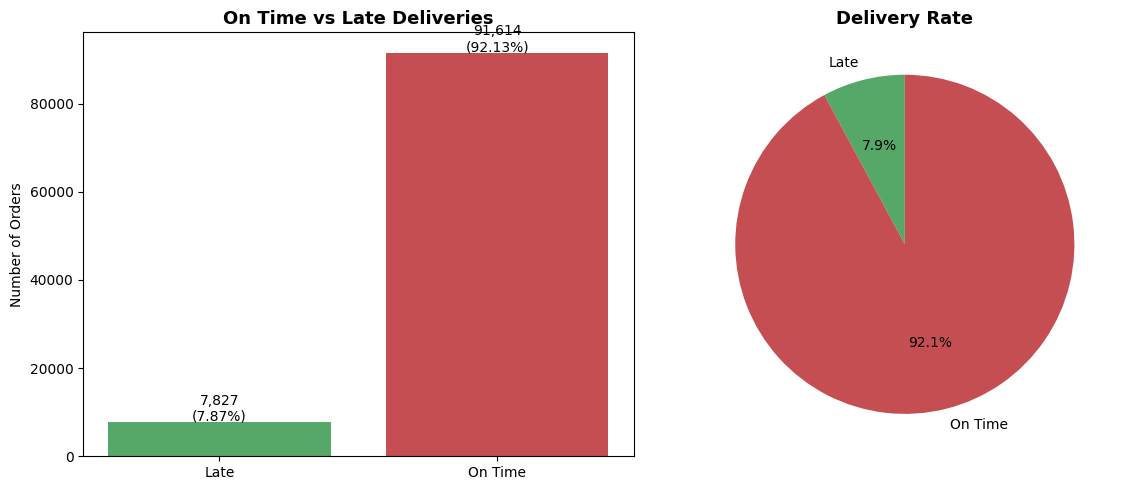

In [15]:
df_delivery = conn.execute("""
    SELECT
        CASE WHEN is_late = 1 THEN 'Late' ELSE 'On Time' END AS delivery_status,
        COUNT(*) AS total_orders,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2) AS percentage
    FROM fact_orders
    WHERE is_late IS NOT NULL
    GROUP BY 1
""").df()

print(df_delivery.to_string(index=False))

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
colors = ["#55A868", "#C44E52"]
ax1.bar(df_delivery["delivery_status"], df_delivery["total_orders"], color=colors)
ax1.set_title("On Time vs Late Deliveries", fontsize=13, fontweight="bold")
ax1.set_ylabel("Number of Orders")
for i, (val, pct) in enumerate(zip(df_delivery["total_orders"], df_delivery["percentage"])):
    ax1.text(i, val + 200, f"{val:,}\n({pct}%)", ha="center", fontsize=10)

# Pie chart
ax2.pie(
    df_delivery["total_orders"],
    labels=df_delivery["delivery_status"],
    colors=colors,
    autopct="%1.1f%%",
    startangle=90
)
ax2.set_title("Delivery Rate", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig("../reports/figures/04_delivery_performance.png", dpi=150, bbox_inches="tight")
plt.show()

In [16]:
## 6. Revenue by Customer State

customer_state  total_orders  total_revenue  avg_order_value
            SP         41746     5202955.05           125.75
            RJ         12852     1824092.67           142.93
            MG         11635     1585308.03           137.33
            RS          5466      750304.02           138.13
            PR          5045      683083.76           136.67
            SC          3637      520553.34           144.12
            BA          3380      511349.99           152.28
            DF          2140      302603.94           142.40
            GO          2020      294591.95           146.78
            ES          2033      275037.31           135.82


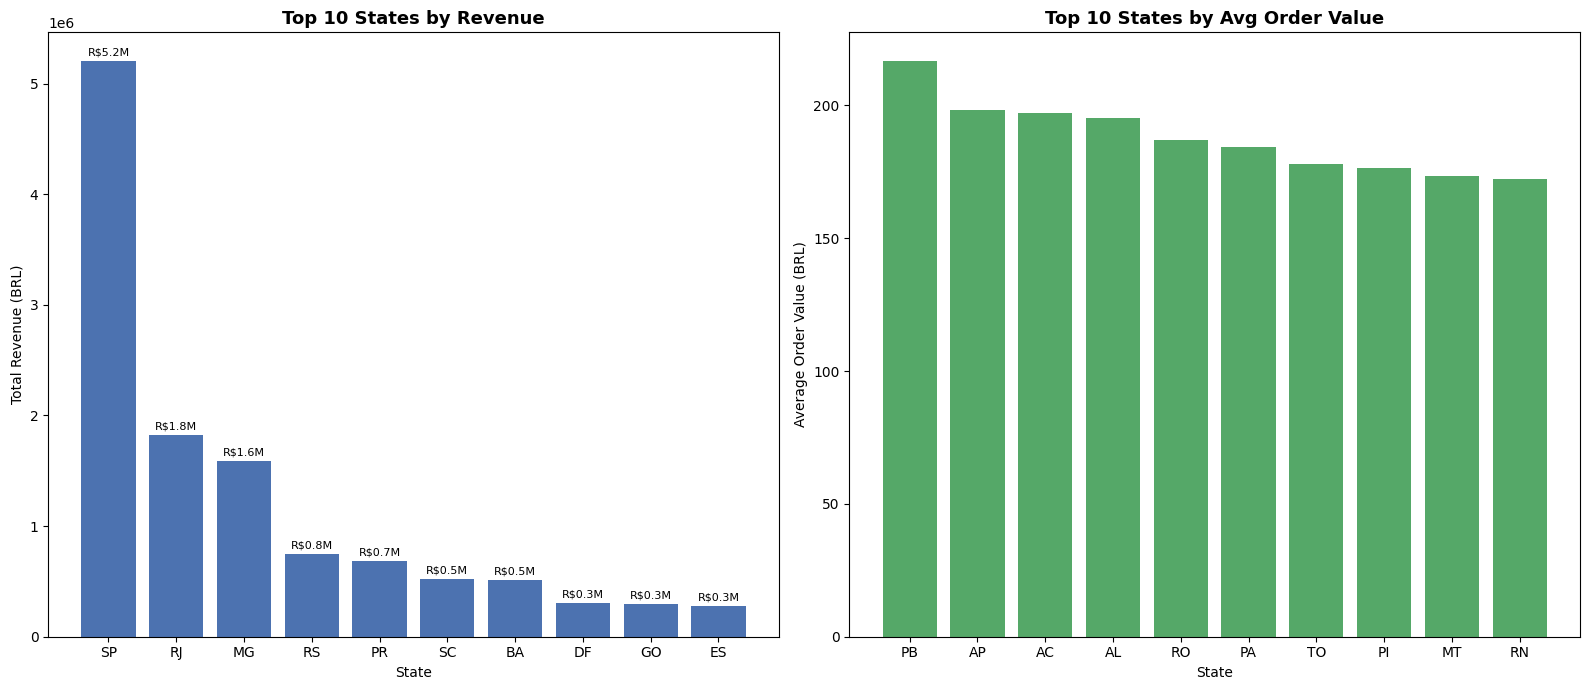

In [17]:
df_states = conn.execute("""
    SELECT
        customer_state,
        COUNT(*) AS total_orders,
        ROUND(SUM(total_price), 2) AS total_revenue,
        ROUND(AVG(total_price), 2) AS avg_order_value
    FROM fact_orders
    WHERE customer_state IS NOT NULL
    GROUP BY 1
    ORDER BY total_revenue DESC
""").df()

print(df_states.head(10).to_string(index=False))

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Top 10 states by revenue
top10 = df_states.head(10)
ax1.bar(top10["customer_state"], top10["total_revenue"], color="#4C72B0")
ax1.set_title("Top 10 States by Revenue", fontsize=13, fontweight="bold")
ax1.set_xlabel("State")
ax1.set_ylabel("Total Revenue (BRL)")
for i, val in enumerate(top10["total_revenue"]):
    ax1.text(i, val + 50000, f"R${val/1e6:.1f}M", ha="center", fontsize=8)

# Average order value by state
top10_avg = df_states.nlargest(10, "avg_order_value")
ax2.bar(top10_avg["customer_state"], top10_avg["avg_order_value"], color="#55A868")
ax2.set_title("Top 10 States by Avg Order Value", fontsize=13, fontweight="bold")
ax2.set_xlabel("State")
ax2.set_ylabel("Average Order Value (BRL)")

plt.tight_layout()
plt.savefig("../reports/figures/05_revenue_by_state.png", dpi=150, bbox_inches="tight")
plt.show()

In [18]:
## 7. Payment Method Analysis

payment_type  total_orders  total_value  avg_installments
 credit_card         76783  12540058.04              3.51
      boleto         19784   2869361.27              1.00
     voucher          5173    363793.38              1.00
  debit_card          1529    217989.79              1.00
 not_defined             3         0.00              1.00


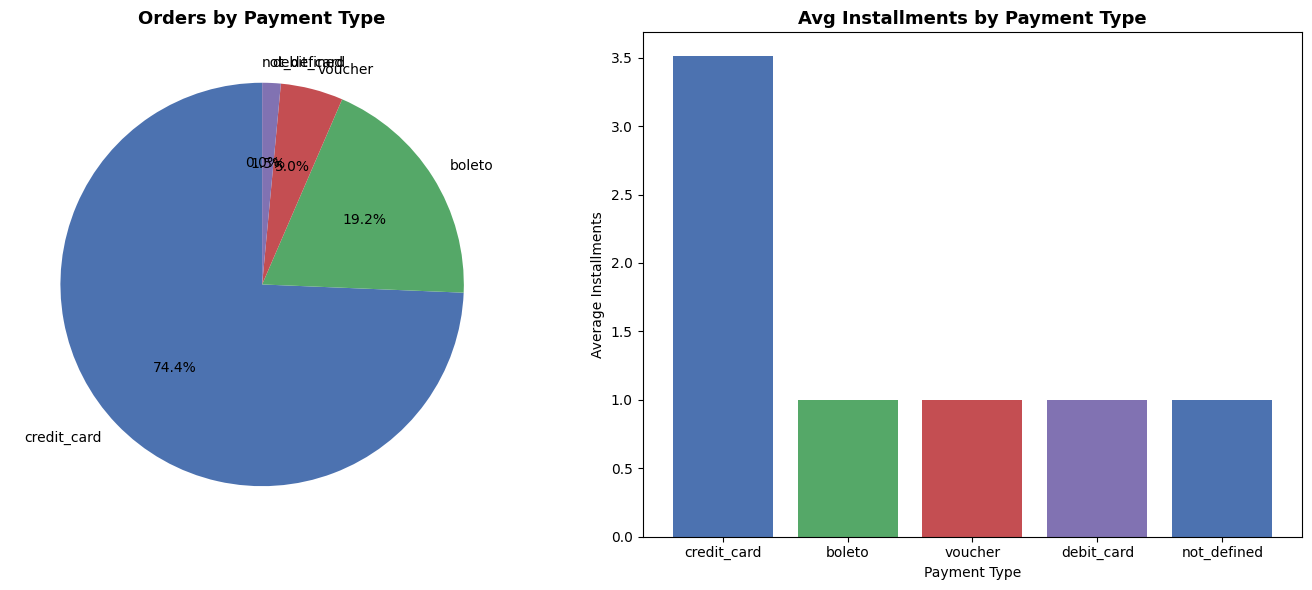

In [19]:
df_payments = conn.execute("""
    SELECT
        payment_type,
        COUNT(*) AS total_orders,
        ROUND(SUM(payment_value), 2) AS total_value,
        ROUND(AVG(payment_installments), 2) AS avg_installments
    FROM dim_payment
    GROUP BY 1
    ORDER BY total_orders DESC
""").df()

print(df_payments.to_string(index=False))

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Orders by payment type
colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]
ax1.pie(
    df_payments["total_orders"],
    labels=df_payments["payment_type"],
    colors=colors,
    autopct="%1.1f%%",
    startangle=90
)
ax1.set_title("Orders by Payment Type", fontsize=13, fontweight="bold")

# Average installments by payment type
ax2.bar(df_payments["payment_type"], df_payments["avg_installments"], color=colors)
ax2.set_title("Avg Installments by Payment Type", fontsize=13, fontweight="bold")
ax2.set_xlabel("Payment Type")
ax2.set_ylabel("Average Installments")

plt.tight_layout()
plt.savefig("../reports/figures/06_payment_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

In [20]:
## 8. Review Score Distribution

 score  total_orders  percentage
   1.0         11316       11.47
   2.0          3133        3.18
   3.0          8171        8.28
   4.0         19044       19.30
   5.0         57009       57.78


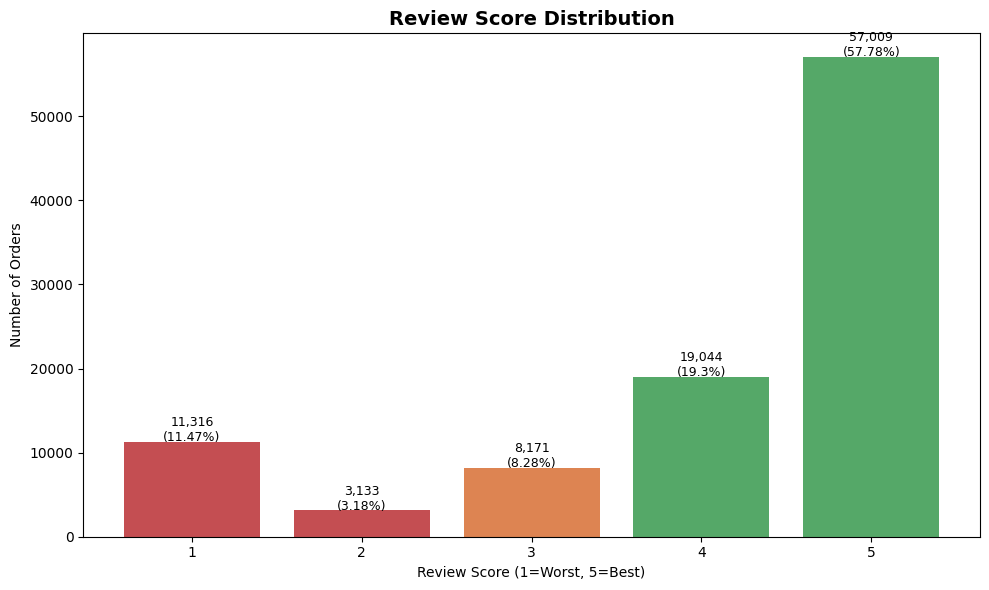

In [21]:
df_reviews = conn.execute("""
    SELECT
        ROUND(review_score) AS score,
        COUNT(*) AS total_orders,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2) AS percentage
    FROM fact_orders
    WHERE review_score IS NOT NULL
    GROUP BY 1
    ORDER BY 1
""").df()

print(df_reviews.to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#C44E52", "#C44E52", "#DD8452", "#55A868", "#55A868"]
bars = ax.bar(df_reviews["score"], df_reviews["total_orders"], color=colors)
ax.set_title("Review Score Distribution", fontsize=14, fontweight="bold")
ax.set_xlabel("Review Score (1=Worst, 5=Best)")
ax.set_ylabel("Number of Orders")
ax.set_xticks([1, 2, 3, 4, 5])

for bar, (val, pct) in zip(bars, zip(df_reviews["total_orders"], df_reviews["percentage"])):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f"{val:,}\n({pct}%)", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("../reports/figures/07_review_scores.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
## 9. RFM Analysis — Customer Segmentation

        segment  total_customers  avg_monetary
        At Risk            33806     85.807084
      Champions            15904    254.007267
           Lost             8025     39.487786
Loyal Customers            40931    154.753814


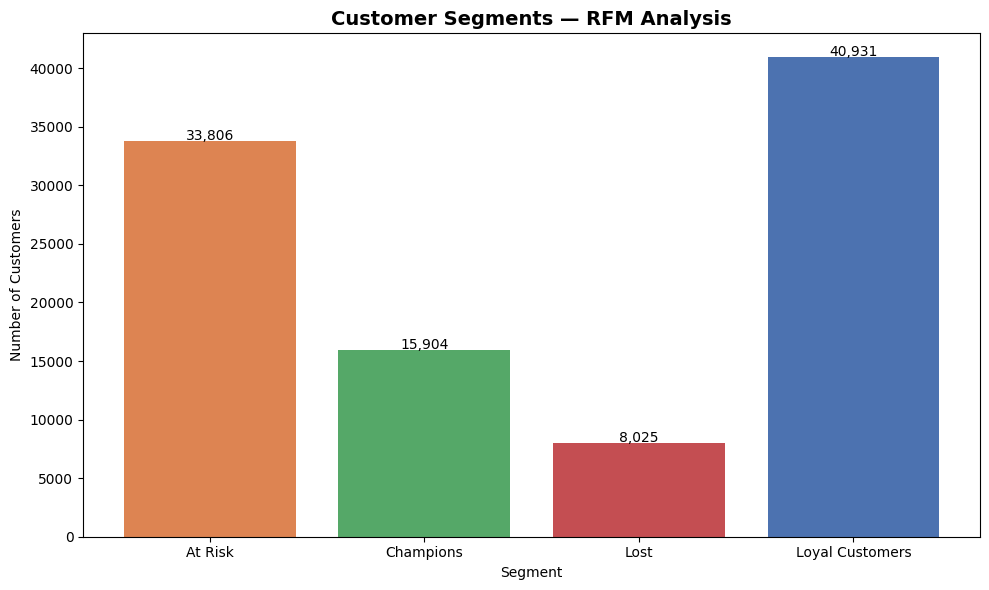

In [23]:
df_rfm = conn.execute("""
    SELECT
        customer_id,
        DATEDIFF('day', MAX(order_purchase_timestamp), '2018-09-03') AS recency,
        COUNT(*) AS frequency,
        ROUND(SUM(total_price), 2) AS monetary
    FROM fact_orders
    WHERE order_purchase_timestamp IS NOT NULL
    GROUP BY 1
""").df()

# Drop nulls before scoring
df_rfm = df_rfm.dropna(subset=["recency", "frequency", "monetary"])

# Score each customer 1-5 on R, F, M
df_rfm["r_score"] = pd.qcut(df_rfm["recency"], q=5, labels=[5,4,3,2,1])
df_rfm["f_score"] = pd.qcut(df_rfm["frequency"].rank(method="first"), q=5, labels=[1,2,3,4,5])
df_rfm["m_score"] = pd.qcut(df_rfm["monetary"], q=5, labels=[1,2,3,4,5])

df_rfm["rfm_score"] = (
    df_rfm["r_score"].astype(float).astype(int) +
    df_rfm["f_score"].astype(float).astype(int) +
    df_rfm["m_score"].astype(float).astype(int)
)

# Segment customers
def segment(score):
    if score >= 12:
        return "Champions"
    elif score >= 9:
        return "Loyal Customers"
    elif score >= 6:
        return "At Risk"
    else:
        return "Lost"

df_rfm["segment"] = df_rfm["rfm_score"].apply(segment)

# Summary
summary = df_rfm.groupby("segment").agg(
    total_customers=("customer_id", "count"),
    avg_monetary=("monetary", "mean")
).reset_index()

print(summary.to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
colors = {"Champions": "#55A868", "Loyal Customers": "#4C72B0",
          "At Risk": "#DD8452", "Lost": "#C44E52"}
bars = ax.bar(
    summary["segment"],
    summary["total_customers"],
    color=[colors[s] for s in summary["segment"]]
)
ax.set_title("Customer Segments — RFM Analysis", fontsize=14, fontweight="bold")
ax.set_xlabel("Segment")
ax.set_ylabel("Number of Customers")

for bar, val in zip(bars, summary["total_customers"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f"{val:,}", ha="center", fontsize=10)

plt.tight_layout()
plt.savefig("../reports/figures/08_rfm_segments.png", dpi=150, bbox_inches="tight")
plt.show()

In [24]:
## 10. Key Business Insights Summary

In [25]:
print("=" * 55)
print("OLIST 360 — KEY BUSINESS INSIGHTS")
print("=" * 55)

total_orders = conn.execute("SELECT COUNT(*) FROM fact_orders").fetchone()[0]
total_revenue = conn.execute("SELECT ROUND(SUM(total_price), 2) FROM fact_orders").fetchone()[0]
avg_order = conn.execute("SELECT ROUND(AVG(total_price), 2) FROM fact_orders").fetchone()[0]
late_pct = conn.execute("SELECT ROUND(AVG(is_late) * 100, 2) FROM fact_orders WHERE is_late IS NOT NULL").fetchone()[0]
top_state = conn.execute("SELECT customer_state FROM fact_orders GROUP BY 1 ORDER BY COUNT(*) DESC LIMIT 1").fetchone()[0]
top_category = conn.execute("""
    SELECT p.product_category_name_english
    FROM fact_orders f
    JOIN dim_product p ON f.product_id = p.product_id
    WHERE p.product_category_name_english IS NOT NULL
    GROUP BY 1
    ORDER BY SUM(f.total_price) DESC
    LIMIT 1
""").fetchone()[0]

print(f"  Total Orders        : {total_orders:,}")
print(f"  Total Revenue       : R${total_revenue:,}")
print(f"  Avg Order Value     : R${avg_order}")
print(f"  Late Delivery Rate  : {late_pct}%")
print(f"  Top State           : {top_state}")
print(f"  Top Category        : {top_category}")
print("=" * 55)

OLIST 360 — KEY BUSINESS INSIGHTS
  Total Orders        : 99,441
  Total Revenue       : R$13,591,643.7
  Avg Order Value     : R$137.75
  Late Delivery Rate  : 7.87%
  Top State           : SP
  Top Category        : health_beauty


In [26]:
conn.close()

In [27]:
conn.close()

BASE_DIR = Path().resolve().parent
conn = duckdb.connect(str(BASE_DIR / "data/warehouse/olist.duckdb"))
print("Connected")

Connected


In [28]:
## 11. Cohort Analysis — Customer Retention by Month

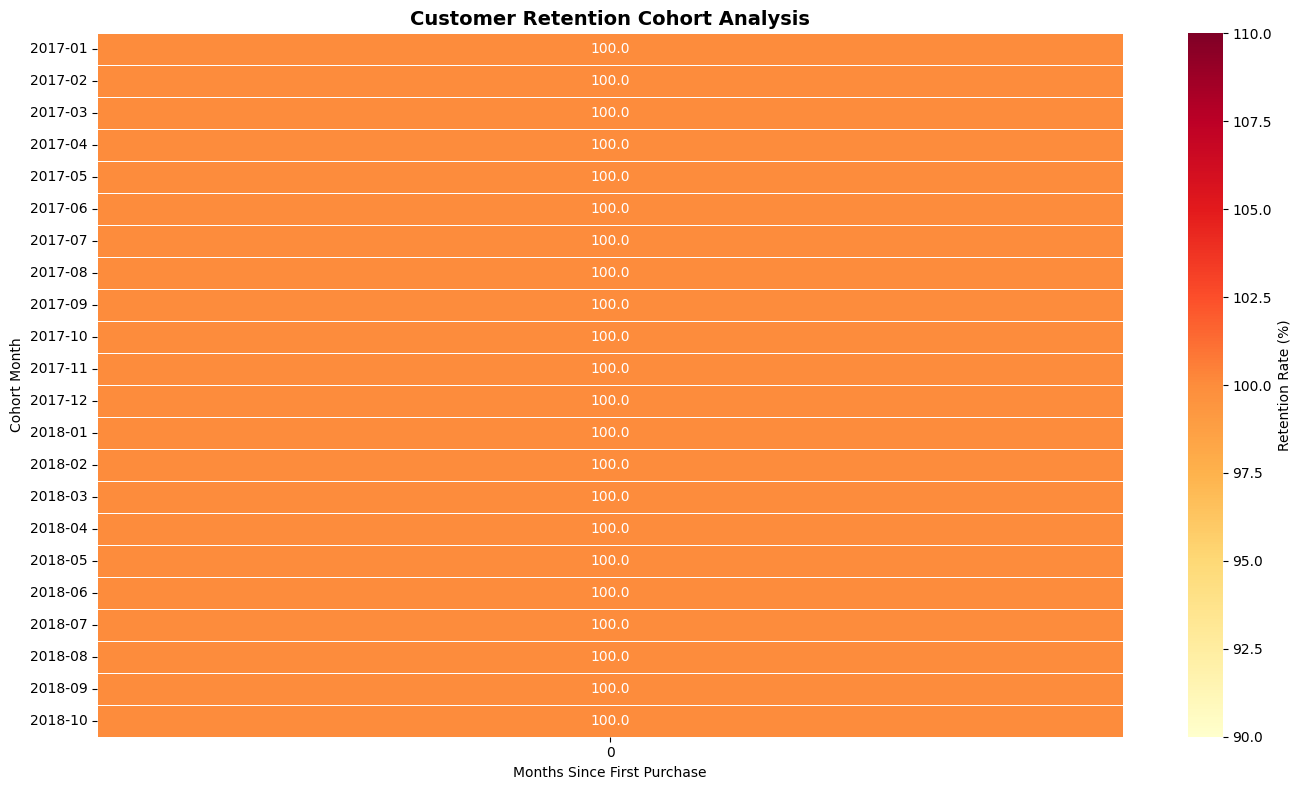

Chart saved


In [29]:
df_cohort = conn.execute("""
    WITH first_purchase AS (
        SELECT
            customer_id,
            DATE_TRUNC('month', MIN(order_purchase_timestamp)) AS cohort_month
        FROM fact_orders
        WHERE order_purchase_timestamp IS NOT NULL
        GROUP BY customer_id
    ),
    order_months AS (
        SELECT
            f.customer_id,
            DATE_TRUNC('month', f.order_purchase_timestamp) AS order_month,
            fp.cohort_month
        FROM fact_orders f
        JOIN first_purchase fp ON f.customer_id = fp.customer_id
    ),
    cohort_data AS (
        SELECT
            cohort_month,
            DATEDIFF('month', cohort_month, order_month) AS month_number,
            COUNT(DISTINCT customer_id) AS customers
        FROM order_months
        GROUP BY 1, 2
    ),
    cohort_size AS (
        SELECT cohort_month, customers AS cohort_customers
        FROM cohort_data
        WHERE month_number = 0
    )
    SELECT
        cd.cohort_month,
        cd.month_number,
        cd.customers,
        cs.cohort_customers,
        ROUND(cd.customers * 100.0 / cs.cohort_customers, 2) AS retention_rate
    FROM cohort_data cd
    JOIN cohort_size cs ON cd.cohort_month = cs.cohort_month
    WHERE cd.cohort_month >= '2017-01-01'
    AND cd.month_number <= 6
    ORDER BY 1, 2
""").df()

# Pivot for heatmap
cohort_pivot = df_cohort.pivot_table(
    index="cohort_month",
    columns="month_number",
    values="retention_rate"
)
cohort_pivot.index = cohort_pivot.index.astype(str).str[:7]

# Plot
fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(
    cohort_pivot,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    ax=ax,
    linewidths=0.5,
    cbar_kws={"label": "Retention Rate (%)"}
)
ax.set_title("Customer Retention Cohort Analysis", fontsize=14, fontweight="bold")
ax.set_xlabel("Months Since First Purchase")
ax.set_ylabel("Cohort Month")
plt.tight_layout()
plt.savefig("../reports/figures/09_cohort_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved")

In [30]:
## 12. Customer Lifetime Value (CLV)


clv_segment  total_customers    avg_clv  avg_orders
        Low            24756  28.595505         1.0
     Medium            24653  63.962895         1.0
       High            24692 115.106669         1.0
    Premium            24565 344.581407         1.0


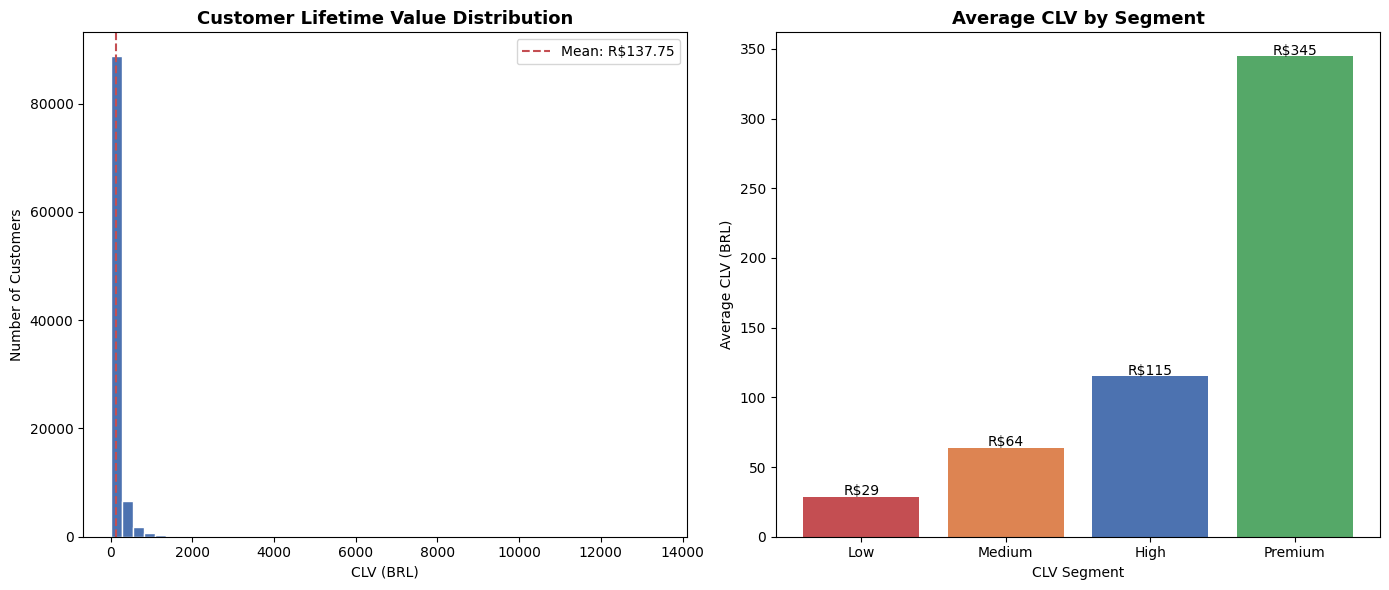

Chart saved


In [31]:
df_clv = conn.execute("""
    SELECT
        customer_id,
        COUNT(*) AS total_orders,
        ROUND(SUM(total_price), 2) AS total_spent,
        ROUND(AVG(total_price), 2) AS avg_order_value,
        DATEDIFF('day',
            MIN(order_purchase_timestamp),
            MAX(order_purchase_timestamp)
        ) AS customer_lifespan_days
    FROM fact_orders
    WHERE order_purchase_timestamp IS NOT NULL
    GROUP BY customer_id
""").df()

# CLV = avg order value x total orders
df_clv["clv"] = df_clv["avg_order_value"] * df_clv["total_orders"]

# Segment by CLV
df_clv["clv_segment"] = pd.qcut(
    df_clv["clv"],
    q=4,
    labels=["Low", "Medium", "High", "Premium"]
)

summary_clv = df_clv.groupby("clv_segment").agg(
    total_customers=("customer_id", "count"),
    avg_clv=("clv", "mean"),
    avg_orders=("total_orders", "mean")
).reset_index()

print(summary_clv.to_string(index=False))

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# CLV distribution
ax1.hist(df_clv["clv"], bins=50, color="#4C72B0", edgecolor="white")
ax1.set_title("Customer Lifetime Value Distribution", fontsize=13, fontweight="bold")
ax1.set_xlabel("CLV (BRL)")
ax1.set_ylabel("Number of Customers")
ax1.axvline(df_clv["clv"].mean(), color="#C44E52", linestyle="--", label=f"Mean: R${df_clv['clv'].mean():.2f}")
ax1.legend()

# CLV by segment
colors = ["#C44E52", "#DD8452", "#4C72B0", "#55A868"]
ax2.bar(summary_clv["clv_segment"], summary_clv["avg_clv"], color=colors)
ax2.set_title("Average CLV by Segment", fontsize=13, fontweight="bold")
ax2.set_xlabel("CLV Segment")
ax2.set_ylabel("Average CLV (BRL)")
for i, val in enumerate(summary_clv["avg_clv"]):
    ax2.text(i, val + 1, f"R${val:.0f}", ha="center", fontsize=10)

plt.tight_layout()
plt.savefig("../reports/figures/10_customer_lifetime_value.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved")

In [32]:
## 13. Geospatial Analysis — Orders by Brazilian State

In [33]:
import folium
from folium.plugins import HeatMap

# Get order counts and revenue by state
df_geo = conn.execute("""
    SELECT
        customer_state,
        COUNT(*) AS total_orders,
        ROUND(SUM(total_price), 2) AS total_revenue,
        ROUND(AVG(is_late) * 100, 2) AS late_rate
    FROM fact_orders
    WHERE customer_state IS NOT NULL
    GROUP BY 1
    ORDER BY total_orders DESC
""").df()

# Brazilian state coordinates
state_coords = {
    "AC": [-9.0238, -70.812], "AL": [-9.5713, -36.782],
    "AM": [-3.4168, -65.856], "AP": [1.4102, -51.770],
    "BA": [-12.960, -38.510], "CE": [-3.7172, -38.543],
    "DF": [-15.780, -47.929], "ES": [-19.183, -40.308],
    "GO": [-15.827, -49.836], "MA": [-2.5297, -44.302],
    "MG": [-18.512, -44.555], "MS": [-20.469, -54.620],
    "MT": [-12.640, -55.420], "PA": [-1.9930, -54.930],
    "PB": [-7.1195, -36.724], "PE": [-8.8137, -36.954],
    "PI": [-7.7183, -42.728], "PR": [-24.890, -51.550],
    "RJ": [-22.912, -43.172], "RN": [-5.8127, -36.204],
    "RO": [-10.830, -63.340], "RR": [1.9900, -61.330],
    "RS": [-30.034, -51.217], "SC": [-27.242, -50.218],
    "SE": [-10.574, -37.385], "SP": [-23.548, -46.636],
    "TO": [-10.240, -48.324]
}

df_geo["lat"] = df_geo["customer_state"].map(lambda x: state_coords.get(x, [None, None])[0])
df_geo["lng"] = df_geo["customer_state"].map(lambda x: state_coords.get(x, [None, None])[1])
df_geo = df_geo.dropna(subset=["lat", "lng"])

# Create folium map centered on Brazil
m = folium.Map(location=[-14.235, -51.925], zoom_start=4, tiles="CartoDB positron")

# Add circle markers for each state
for _, row in df_geo.iterrows():
    folium.CircleMarker(
        location=[row["lat"], row["lng"]],
        radius=row["total_orders"] / 2000,
        color="#C44E52",
        fill=True,
        fill_color="#4C72B0",
        fill_opacity=0.6,
        popup=folium.Popup(
            f"""
            <b>{row['customer_state']}</b><br>
            Orders: {row['total_orders']:,}<br>
            Revenue: R${row['total_revenue']:,}<br>
            Late Rate: {row['late_rate']}%
            """,
            max_width=200
        ),
        tooltip=f"{row['customer_state']} — {row['total_orders']:,} orders"
    ).add_to(m)

# Save map
map_path = BASE_DIR / "reports/figures/11_brazil_orders_map.html"
m.save(str(map_path))
print(f"Map saved to {map_path}")
print("Open reports/figures/11_brazil_orders_map.html in your browser to see the interactive map")

Map saved to C:\Users\razin\Projects\olist-360\reports\figures\11_brazil_orders_map.html
Open reports/figures/11_brazil_orders_map.html in your browser to see the interactive map
